# Test

In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import scipy.constants as spconsts

In [2]:
from heliumtools.simulation.GPE.bec2D import Gas
import heliumtools.simulation.GPE.utils.callbacks as call
#import heliumtools.simulation.GPE.bec2D.callbacks as call2
import heliumtools.simulation.GPE.bec2D.potentials as potentials
from heliumtools.simulation.GPE.utils.potentials import s_ramp , quench

/home/rui/HeliumTools/hellenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Finding Ground state BEC

In [10]:
bec = Gas(element = "He*" , N_particles=1e4, grid_size=5e-5 , device = "cpu")

In [11]:
# compute 2D-harmonic ocscillator ground state along y = 0
m = 6.65*10**(-27)
hbar = 1.054*10**(-34)
omega = 2*np.pi*1e3
alpha = m*omega/hbar
phiHarmonic = np.power(alpha*bec.adim_length**2/np.pi,1/2)*torch.exp(-alpha/2*(bec.X**2+bec.Y**2)*bec.adim_length**2)

bec.psi = phiHarmonic

In [21]:
abot = np.sqrt(hbar/(m*2*np.pi*40))/spconsts.codata.value("Bohr radius")
a_s = 7e-9/spconsts.codata.value("Bohr radius")
contact = potentials.Contact(a_s = a_s , a_orth = 0.1*a_s)
trap = potentials.Trap(omegax = 1e3, omegay = 1e3)

/tmp/ipykernel_520079/740323300.py:1: DeprecationWarning: Please import `value` from the `scipy.constants` namespace; the `scipy.constants.codata` namespace is deprecated and will be removed in SciPy 2.0.0.
  abot = np.sqrt(hbar/(m*2*np.pi*40))/spconsts.codata.value("Bohr radius")
/tmp/ipykernel_520079/740323300.py:2: DeprecationWarning: Please import `value` from the `scipy.constants` namespace; the `scipy.constants.codata` namespace is deprecated and will be removed in SciPy 2.0.0.
  a_s = 7e-9/spconsts.codata.value("Bohr radius")


In [22]:
convergence = call.L1Norm(compute_every = 500, print_every = 1e4)
bec.ground_state(potentials=[trap,contact], N_iterations=5e3,callbacks=[convergence])

Ground state:   0%|          | 0/5000 [00:00<?]

Ground state:   0%|          | 3/5000 [00:00<06:59]

tensor(8.9386e-08, dtype=torch.float64)


Ground state: 100%|██████████| 5000/5000 [04:53<00:00]


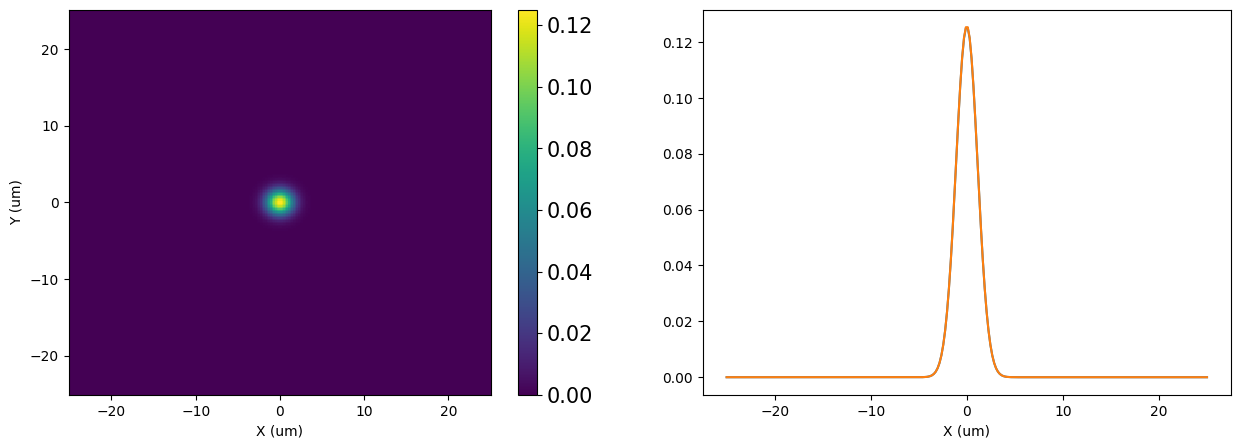

In [24]:
fig, ax = plt.subplots(nrows= 1 , ncols=2,figsize = (15,5))


# plot
im = ax[0].pcolormesh(bec.X*bec.adim_length*1e6,bec.Y*bec.adim_length*1e6, bec.density)
cbar = fig.colorbar(im, ax = ax[0])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)

ax[1].plot(bec.X[0]*bec.adim_length*1e6,bec.density[int(len(bec.density)/2)])

# plot original guess which is the quantum harmonic oscillator
ax[1].plot(bec.X[0]*bec.adim_length*1e6,phiHarmonic[int(len(phiHarmonic)/2)]**2)

ax[0].set_xlabel("X (um)")
ax[0].set_ylabel("Y (um)")
ax[1].set_xlabel("X (um)")

plt.show()

Text(0.5, 1.0, 'Convergence of calculation')

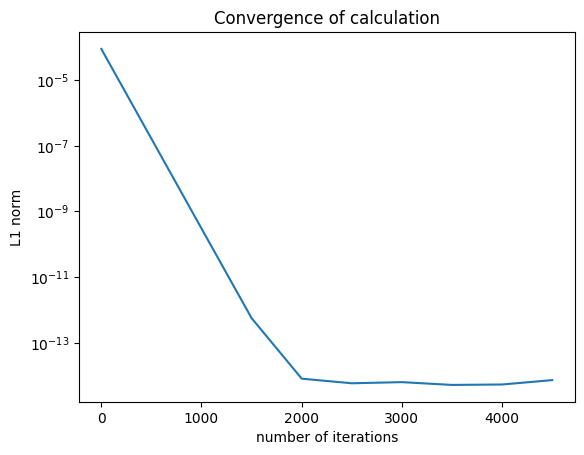

In [15]:
plt.plot(np.arange(1,5e3+1,500),convergence.norms)
plt.xlabel("number of iterations")
plt.ylabel("L1 norm")
plt.yscale("log")
plt.title("Convergence of calculation")

## Quench BEC

In [69]:
depth = quench(v0=1e3, v1=0, quench_time=100e-6)
trap = potentials.Trap(omegax=depth, omegay=depth)

In [70]:
bec.propagate(500e-6, 1e-6, [trap, contact])

Propagation: 100%|██████████| 500/500 [00:23<00:00]


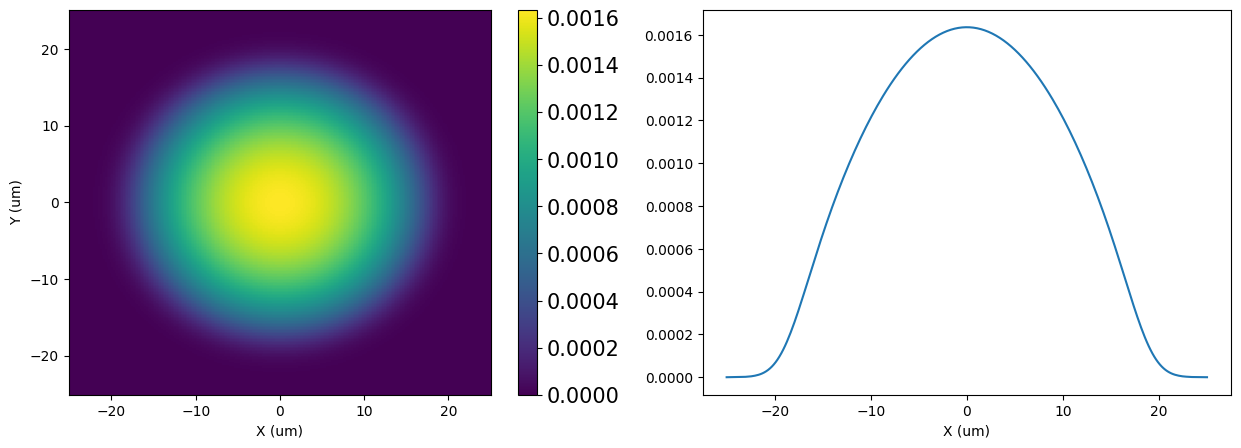

In [76]:
fig, ax = plt.subplots(nrows= 1 , ncols=2,figsize = (15,5))


# plot
im = ax[0].pcolormesh(bec.X*bec.adim_length*1e6,bec.Y*bec.adim_length*1e6, bec.density)
cbar = fig.colorbar(im, ax = ax[0])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)

ax[1].plot(bec.X[0]*bec.adim_length*1e6,bec.density[int(len(bec.density)/2)])

# plot original guess which is the quantum harmonic oscillator
#ax[1].plot(bec.X[0]*bec.adim_length*1e6,phiHarmonic[int(len(phiHarmonic)/2)]**2)

ax[0].set_xlabel("X (um)")
ax[0].set_ylabel("Y (um)")
ax[1].set_xlabel("X (um)")

plt.show()

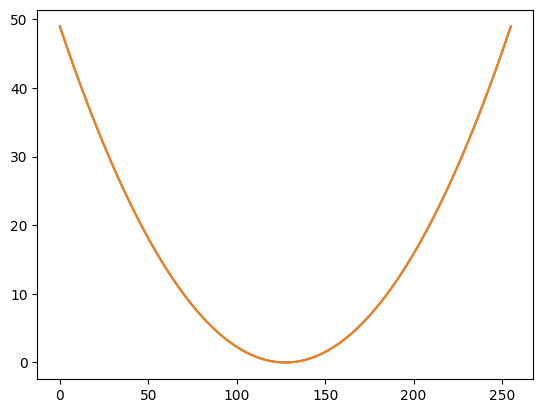

In [75]:
plt.plot(trap.get_potential(bec.X[0],0.0,0))
plt.plot(trap.get_potential(bec.X[0],0.0,99e-6))

In [77]:
bec.adim_length

1e-06

In [8]:
depth = s_ramp(0, 0, 15, 1e-3)
#cavity = potentials.DispersiveCavity(lattice_depth=depth, cavity_detuning=-15e6, atomic_detuning=-76.6e9, 
#                                     cavity_decay=150e3, cavity_coupling=1.95e6)
lattice = potentials.Lattice(V0 = depth,lam = 1.064e-6)

bec.propagate(2e-3, 1e-6, [lattice, trap, contact])

Propagation: 100%|██████████| 2000/2000 [01:55<00:00]


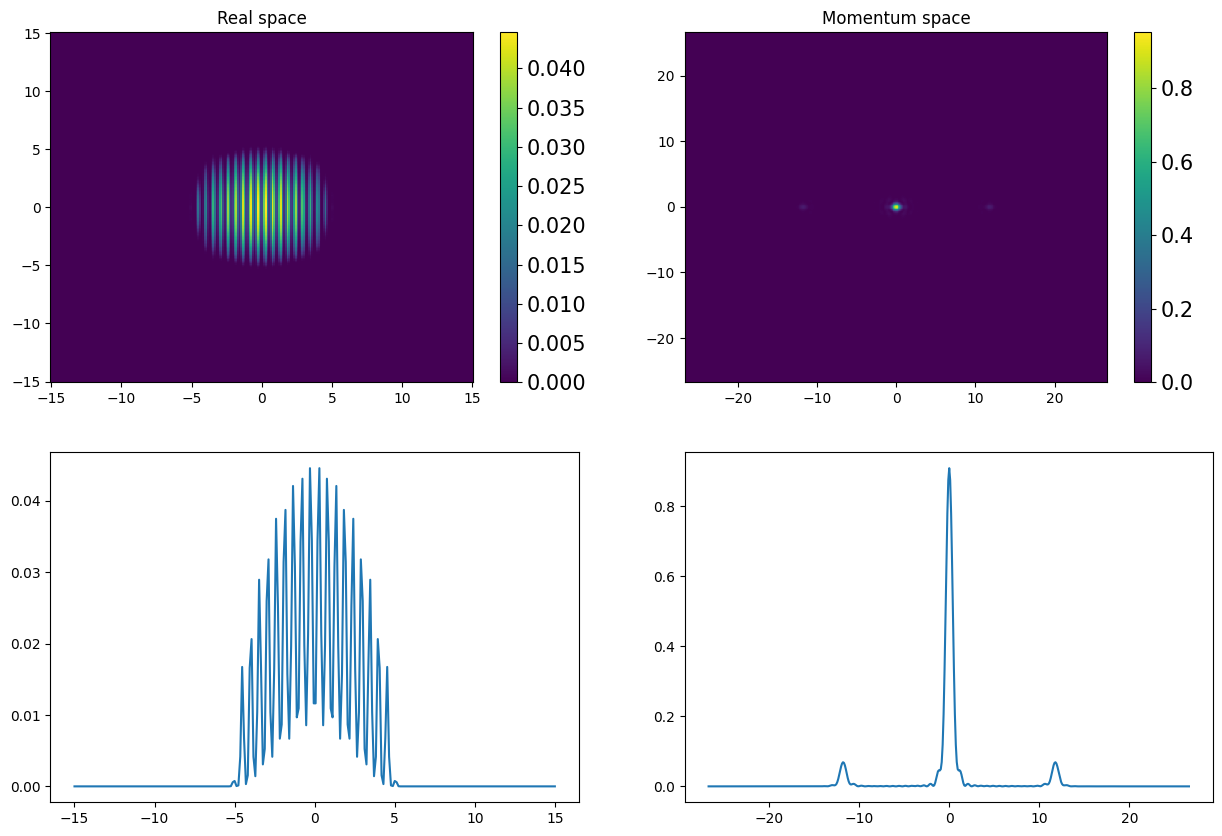

In [9]:
fig, ax = plt.subplots(nrows= 2 , ncols=2,figsize = (15,10))


# plot
im = ax[0,0].pcolormesh(bec.X,bec.Y, bec.density)
cbar = fig.colorbar(im, ax = ax[0,0])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)
ax[0,0].set_title("Real space")

# plot
im = ax[0,1].pcolormesh(bec.Kx,bec.Ky, bec.densityk)
cbar = fig.colorbar(im, ax = ax[0,1])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)
ax[0,1].set_title("Momentum space")


ax[1,0].plot(bec.X[0],bec.density[int(len(bec.density)/2)-1])
ax[1,1].plot(bec.Kx[0],bec.densityk[int(len(bec.densityk)/2)-1])


plt.show()
